In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier


In [77]:
X = np.load("X_train_rdkit_desc.npy")
X_test = np.load("X_test_rdkit_desc.npy")
y = pd.read_csv("training_smiles.csv")["ACTIVE"].to_numpy()


In [78]:
print("Shapes:", X.shape, X_test.shape, y.shape)

Shapes: (202895, 8) (67631, 8) (202895,)


In [79]:
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=200, class_weight="balanced", n_jobs=-1, solver="lbfgs")
)
clf.fit(Xtr, ytr)

va_pred_lr = clf.predict_proba(Xva)[:, 1]
log_val_auc = roc_auc_score(yva, va_pred_lr)
print("Validation AUC:", log_val_auc)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv_scores = cross_val_score(
    clf,
    X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("LogReg CV AUC mean ± std:",
      log_cv_scores.mean(), log_cv_scores.std())


Validation AUC: 0.7289372198681469
LogReg CV AUC mean ± std: 0.7333464673759911 0.003631299881663072


In [80]:
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define the forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=1,
    n_jobs=-1,
    class_weight="balanced_subsample",  # helps with the 0/1 imbalance
    random_state=42,
    oob_score=True,                     # optional; needs bootstrap (default True)
)

# Fit
rf.fit(Xtr, ytr)

# Validation AUC
va_pred_rf = rf.predict_proba(Xva)[:, 1]
rf_val_auc  = roc_auc_score(yva, va_pred_rf)
print("Validation AUC:", rf_val_auc)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    rf,
    X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("RandomForest CV AUC mean ± std:",
      rf_cv_scores.mean(), rf_cv_scores.std())
#print("OOB score (if enabled):", rf.oob_score_)

Validation AUC: 0.8101700115549962


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomForest CV AUC mean ± std: 0.8113076800846638 0.00475456555345633


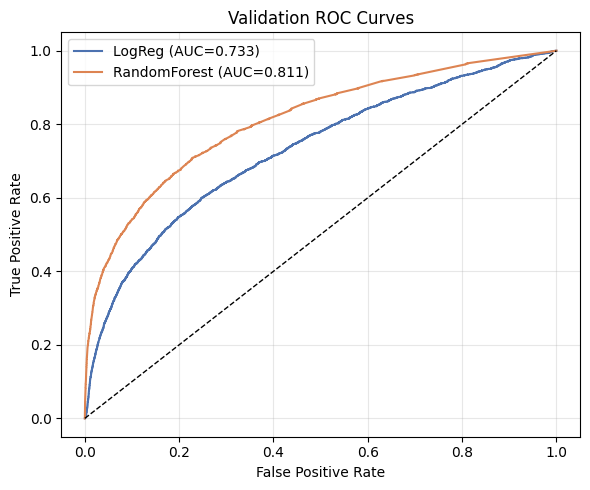

In [81]:
 # ROC curves
fpr_log, tpr_log, _ = roc_curve(yva, va_pred_lr)
fpr_rf,  tpr_rf,  _ = roc_curve(yva, va_pred_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f"LogReg (AUC={log_cv_scores.mean():.3f})", color="#4c72b0")
plt.plot(fpr_rf,  tpr_rf,  label=f"RandomForest (AUC={rf_cv_scores.mean():.3f})", color="#dd8452")
plt.plot([0,1], [0,1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("validation_roc_8.png", dpi=300, bbox_inches="tight")
plt.show()
